### Importando os pacotes

In [ ]:
# importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
import seaborn as sns
import numpy as np

import eda_lib as eda
import regressao_log_lib as rl
import hipoteses_lib as ht
from importlib import reload

from statistics import covariance
from scipy.stats import variation, pearsonr, kurtosis, skew, shapiro, pearsonr, kruskal, boxcox, describe, mannwhitneyu, contingency, chi2_contingency
from scikit_posthocs import posthoc_dunn
import statsmodels as sm
import statsmodels.api as sma
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.stats import anova, api
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

In [2]:
# configurando o ambiente de visualização
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

### Carregando o dataset

In [3]:
# carregando o dataset
df_crm = pd.read_csv('../data/crm_eda_univariada.csv', sep=',')
df_crm.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Idade,faixa_etaria,faixa_renda_anual,tem_filhos,total_filhos,total_gasto,total_compras,ticket_medio,total_campanhas_aceitas,faixa_recencia,pct_gasto_vinhos,pct_gasto_frutas,pct_gasto_carnes,pct_gasto_peixes,pct_gasto_doces,pct_gasto_premium,cliente_aceita_campanha,pct_compras_deals,pct_compras_web,pct_compras_catalog,pct_compras_store,canal_preferencial,nivel_educacional,estado_civil
0,1957,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,69,60_mais,Alta,0,0,1617,25,64.680000,0,Recente,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0,0.120000,0.320000,0.400000,0.160000,Catalogo,medio,Single
1,1954,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,72,60_mais,Media,1,2,27,6,4.500000,0,Recente,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0,0.333333,0.166667,0.166667,0.333333,Loja,medio,Single
2,1965,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,61,60_mais,Muito_Alta,0,0,776,21,36.952381,0,Muito_Recente,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0,0.047619,0.380952,0.095238,0.476190,Loja,medio,Together
3,1984,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,42,41_50,Baixa,1,1,53,8,6.625000,0,Muito_Recente,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0,0.250000,0.250000,0.000000,0.500000,Loja,medio,Together
4,1981,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,45,41_50,Alta,1,1,422,19,22.210526,0,Inativo,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0,0.263158,0.263158,0.157895,0.315789,Loja,alto,Married


### EDA - Análise Exploratória bivariada

In [4]:
eda_crm = eda.Eda_lib(dataframe=df_crm, nome='df_crm',colormap='tab20')

In [5]:
print(eda_crm)

O dataset df_crm possui 2240 registros e 47 colunas.
------------------------------------------------------------------------
Year_Birth                   int64
Income                     float64
Kidhome                      int64
Teenhome                     int64
Recency                      int64
MntWines                     int64
MntFruits                    int64
MntMeatProducts              int64
MntFishProducts              int64
MntSweetProducts             int64
MntGoldProds                 int64
NumDealsPurchases            int64
NumWebPurchases              int64
NumCatalogPurchases          int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
AcceptedCmp3                 int64
AcceptedCmp4                 int64
AcceptedCmp5                 int64
AcceptedCmp1                 int64
AcceptedCmp2                 int64
Complain                     int64
Response                     int64
Idade                        int64
faixa_etaria                   str

In [6]:
# separando as variáveis numéricas e categóricas
var_binarias = ['Complain', 'Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'tem_filhos', 'cliente_aceita_campanha']
var_numericas = [item for item in df_crm.select_dtypes(include=['int64', 'float64']).columns.tolist() if item not in var_binarias]
var_categoricas = df_crm.select_dtypes(include=['object']).columns.tolist()
# var_categoricas.extend(var_binarias)

In [7]:
var_categoricas

['faixa_etaria',
 'faixa_renda_anual',
 'faixa_recencia',
 'canal_preferencial',
 'nivel_educacional',
 'estado_civil']

In [8]:
var_numericas

['Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Idade',
 'total_filhos',
 'total_gasto',
 'total_compras',
 'ticket_medio',
 'total_campanhas_aceitas',
 'pct_gasto_vinhos',
 'pct_gasto_frutas',
 'pct_gasto_carnes',
 'pct_gasto_peixes',
 'pct_gasto_doces',
 'pct_gasto_premium',
 'pct_compras_deals',
 'pct_compras_web',
 'pct_compras_catalog',
 'pct_compras_store']

#### Verificando a multicolinearidade entre as variáveis independentes numéricas

In [41]:
reload(eda)

<module 'eda_lib' from 'd:\\Repositorio\\DataScience\\Case\\crm_varejo_alimenticio\\crm_varejo_alimenticio\\eda_lib.py'>

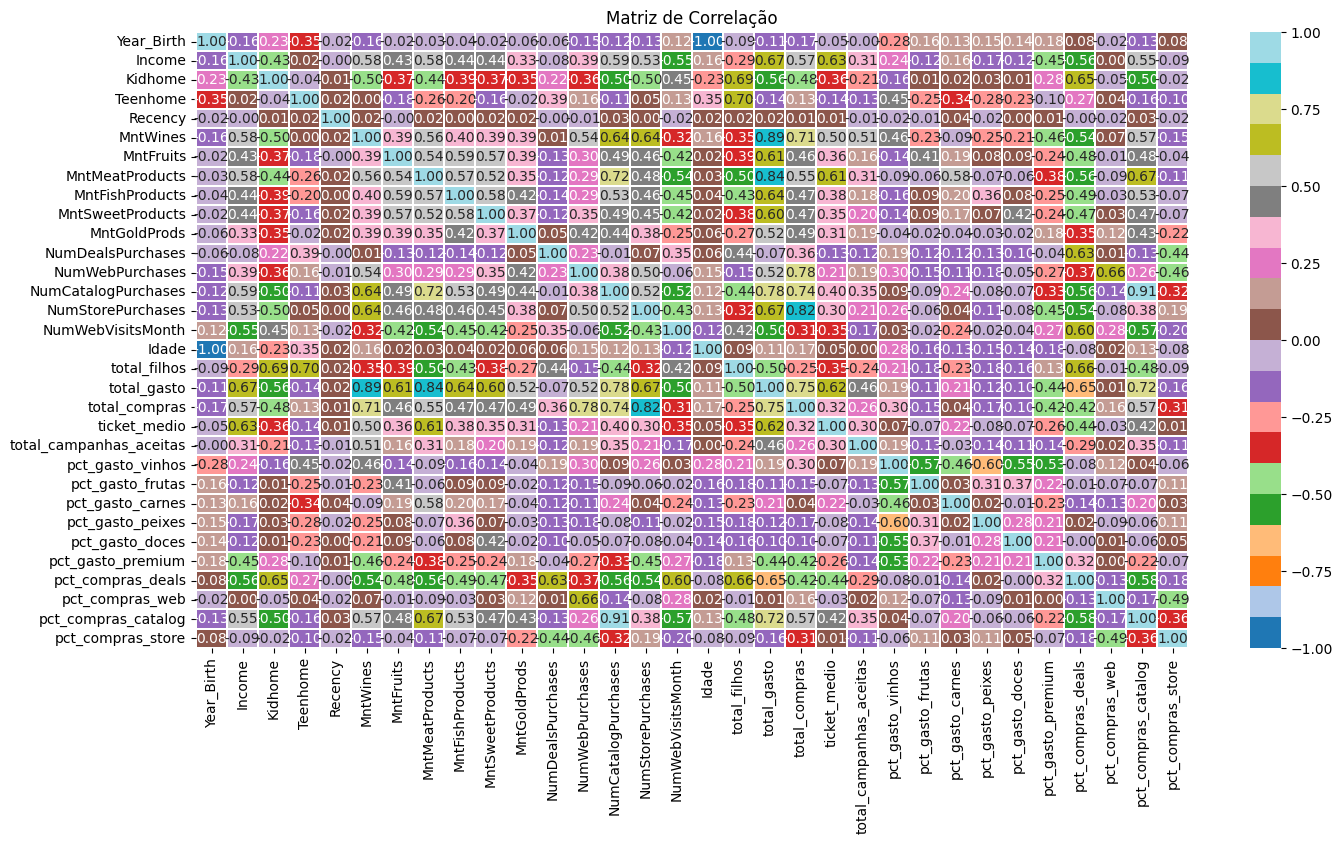


Threshold (corte): 0.7
                      X1                   X2      Corr
16            Year_Birth                Idade -1.000000
178             MntWines          total_gasto  0.891839
179             MntWines        total_compras  0.712789
237      MntMeatProducts  NumCatalogPurchases  0.723827
242      MntMeatProducts          total_gasto  0.842965
403      NumWebPurchases        total_compras  0.777831
423  NumCatalogPurchases      MntMeatProducts  0.723827
434  NumCatalogPurchases          total_gasto  0.778577
435  NumCatalogPurchases        total_compras  0.735198
446  NumCatalogPurchases  pct_compras_catalog  0.912028
467    NumStorePurchases        total_compras  0.820259
512                Idade           Year_Birth -1.000000
581          total_gasto             MntWines  0.891839
583          total_gasto      MntMeatProducts  0.842965
589          total_gasto  NumCatalogPurchases  0.778577
595          total_gasto        total_compras  0.753903
606          total_gasto

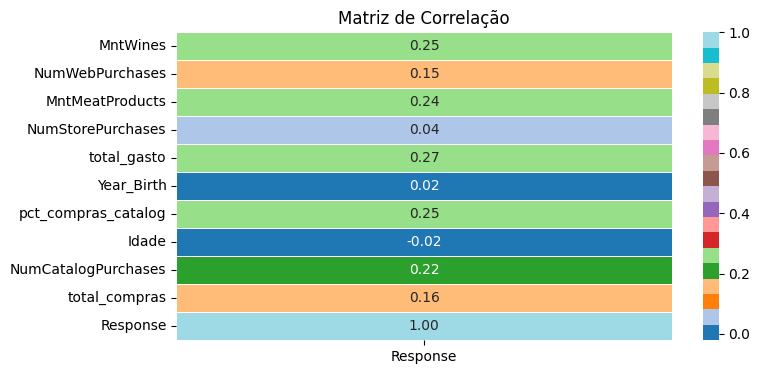

In [52]:
# testando a correlação entre as variáveis numéricas
eda_crm.pearson_corr(target='Response', var_numericas=var_numericas, threshold=0.7)

#### Analisando o VIF

In [263]:
def calcular_vif(df, variaveis):
    
    X = df[variaveis].copy()
    
    # remover missing (VIF não aceita NaN)
    X = X.dropna()
    
    # adicionar constante
    X = sma.add_constant(X)
    
    vif_data = pd.DataFrame()
    vif_data["variavel"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    
    return vif_data.sort_values(by="VIF", ascending=False)

In [23]:
var_vif = var_numericas + var_categoricas + var_binarias

In [11]:
var_vif

['Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Idade',
 'total_filhos',
 'total_gasto',
 'total_compras',
 'ticket_medio',
 'total_campanhas_aceitas',
 'pct_gasto_vinhos',
 'pct_gasto_frutas',
 'pct_gasto_carnes',
 'pct_gasto_peixes',
 'pct_gasto_doces',
 'pct_gasto_premium',
 'pct_compras_deals',
 'pct_compras_web',
 'pct_compras_catalog',
 'pct_compras_store',
 'faixa_etaria',
 'faixa_renda_anual',
 'faixa_recencia',
 'canal_preferencial',
 'nivel_educacional',
 'estado_civil',
 'Complain',
 'Response',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'tem_filhos',
 'cliente_aceita_campanha']

In [14]:
var_binarias

['Complain',
 'Response',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'tem_filhos',
 'cliente_aceita_campanha']

In [12]:
var_categoricas

['faixa_etaria',
 'faixa_renda_anual',
 'faixa_recencia',
 'canal_preferencial',
 'nivel_educacional',
 'estado_civil']

In [24]:
dummies_vif = pd.get_dummies(
    df_crm[var_vif],
    columns=['nivel_educacional','estado_civil','faixa_etaria',  'faixa_renda_anual', 'faixa_recencia', 'canal_preferencial'], 
    drop_first=True, dtype=int
)

In [25]:
dummies_vif.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Idade,total_filhos,total_gasto,total_compras,ticket_medio,total_campanhas_aceitas,pct_gasto_vinhos,pct_gasto_frutas,pct_gasto_carnes,pct_gasto_peixes,pct_gasto_doces,pct_gasto_premium,pct_compras_deals,pct_compras_web,pct_compras_catalog,pct_compras_store,Complain,Response,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,tem_filhos,cliente_aceita_campanha,nivel_educacional_baixo,nivel_educacional_medio,estado_civil_Married,estado_civil_Outros,estado_civil_Single,estado_civil_Together,estado_civil_Widow,faixa_etaria_31_40,faixa_etaria_41_50,faixa_etaria_51_60,faixa_etaria_60_mais,faixa_renda_anual_Baixa,faixa_renda_anual_Media,faixa_renda_anual_Muito_Alta,faixa_recencia_Muito_Recente,faixa_recencia_Pouco_Ativo,faixa_recencia_Recente,canal_preferencial_Loja,canal_preferencial_Web
0,1957,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,69,0,1617,25,64.680000,0,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.120000,0.320000,0.400000,0.160000,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1,1954,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,72,2,27,6,4.500000,0,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.333333,0.166667,0.166667,0.333333,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,1,0
2,1965,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,61,0,776,21,36.952381,0,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.047619,0.380952,0.095238,0.476190,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0
3,1984,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,42,1,53,8,6.625000,0,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.250000,0.250000,0.000000,0.500000,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0
4,1981,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,45,1,422,19,22.210526,0,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.263158,0.263158,0.157895,0.315789,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [26]:
calcular_vif(dummies_vif, dummies_vif.columns.tolist())

,variavel,VIF
1,Year_Birth,inf
4,Teenhome,inf
3,Kidhome,inf
7,MntFruits,inf
6,MntWines,inf
...,...,...
43,nivel_educacional_medio,1.406164
48,estado_civil_Widow,1.314322
45,estado_civil_Outros,1.051055
33,Complain,1.035944


#### Conclusões
O que o VIF mede?
- Mede quanto uma variável pode ser explicada pelas demais

Na tabela acima vemos uma grande quantidade de valore `inf` para VIF, isso mostra que existe dependência matemática direta entre várias features. Quando aparece uma quantidade tão grande de inf, normalmente significa que existem variáveis construídas umas a partir das outras.

Quando o VIF é infinito, geralmente ocorre:
- X = combinação linear exata de outras variáveis
- total_gasto = MntWines + MntMeatProducts + MntFruits + MntSweetProducts + MntFishProducts + MntGoldProds

Adotaremos a seguinte premissa:
- VIF > 10  -> agir
- 5–10      -> investigar
- <5        -> seguir

O que iremos fazer a seguir é retirar algumas variáveis redundantes.

- Idade = Year_Birth => manter Idade
- total_filhos = Kidhome + Teenhome => mater total_filhos
- total_gasto = MntWines + MntMeatProducts + MntFruits + MntSweetProducts + MntFishProducts + MntGoldProds
- pct_gasto_doces, pct_gasto_frutas, pct_gasto_peixes, pct_gasto_carnes, pct_gasto_vinhos, pct_gasto_premium
    - remover total_gasto e pct_gasto_*, pois com o montante gasto por categoria, podemos traçar um perfil de consumo mais preciso.
- remover NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumDealsPurchases
    - Manter total_compras, pct_compras_store, pct_compras_web, pct_compras_catalog, pct_compras_deals => são utilizadas para definir o canal_preferencial
-  manter ticket_medio 
- total_campanhas_aceitas = AcceptedCmp1 + AcceptedCmp2 + AcceptedCmp3 + AcceptedCmp4 + AcceptedCmp5 => total_campanhas_aceitas

In [27]:
dummies_vif.drop(columns=['Year_Birth', 'Kidhome', 'Teenhome'
                          , 'total_gasto', 'pct_gasto_doces', 'pct_gasto_frutas'
                          , 'pct_gasto_peixes', 'pct_gasto_carnes', 'pct_gasto_vinhos'
                          ,'pct_gasto_premium', 'NumWebPurchases', 'NumCatalogPurchases'
                          , 'NumStorePurchases', 'NumDealsPurchases', 'AcceptedCmp1'
                          , 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4'
                            , 'AcceptedCmp5'], inplace=True)

In [28]:
calcular_vif(dummies_vif, dummies_vif.columns.tolist())

,variavel,VIF
0,const,1660.767953
33,faixa_etaria_60_mais,113.478483
32,faixa_etaria_51_60,109.951880
31,faixa_etaria_41_50,95.951574
30,faixa_etaria_31_40,45.458590
37,faixa_recencia_Muito_Recente,23.024283
13,ticket_medio,14.449383
17,pct_compras_catalog,13.231939
2,Recency,12.029341
39,faixa_recencia_Recente,10.170180


Observamos na tabela acima que conseguimos eliminar as variáveis cujo VIF apresentava o valor `inf`. Porém algumas variáveis ainda possuem o valor de VIF alto (>5).
- Vamos manter Idade e remover as faixas etárias (maior VIF)
- Vamos manter faixas de recencia e remover Recency

In [29]:
dummies_vif.drop(columns=['faixa_etaria_60_mais','faixa_etaria_51_60','faixa_etaria_41_50',
                          'faixa_etaria_31_40','Recency'],inplace=True)

In [30]:
calcular_vif(dummies_vif, dummies_vif.columns.tolist())

,variavel,VIF
0,const,722.578488
12,ticket_medio,14.366777
16,pct_compras_catalog,13.216831
14,pct_compras_deals,9.746183
2,MntWines,9.248340
17,pct_compras_store,8.982906
15,pct_compras_web,6.821935
11,total_compras,6.521505
4,MntMeatProducts,5.223684
35,canal_preferencial_Loja,5.178923


Ainda temos variáveis com o valor de VIF alto.
- Vamos remover: ticket_medio, pct_compras_catalog, pct_compras_deals, pct_compras_store, pct_compras_web

In [31]:
dummies_vif.drop(columns=['ticket_medio', 'pct_compras_catalog', 'pct_compras_deals'
                          , 'pct_compras_store', 'pct_compras_web'], inplace=True)

In [32]:
calcular_vif(dummies_vif, dummies_vif.columns.tolist())

,variavel,VIF
0,const,125.300039
12,total_campanhas_aceitas,4.598754
24,faixa_renda_anual_Baixa,4.454743
16,cliente_aceita_campanha,3.943108
2,MntWines,3.571717
31,canal_preferencial_Web,3.527312
15,tem_filhos,3.479871
30,canal_preferencial_Loja,3.452177
11,total_compras,3.335983
27,faixa_recencia_Muito_Recente,3.274437


- O utltimo ajuste sera eliminar a redundancia total_filhos e tem_filhos. Vamos manter total_filhos.

In [33]:
dummies_vif.drop(columns=['tem_filhos'], inplace=True)

In [34]:
calcular_vif(dummies_vif, dummies_vif.columns.tolist())

,variavel,VIF
0,const,121.843380
12,total_campanhas_aceitas,4.587418
23,faixa_renda_anual_Baixa,4.453444
15,cliente_aceita_campanha,3.942590
2,MntWines,3.570479
30,canal_preferencial_Web,3.524633
29,canal_preferencial_Loja,3.451806
11,total_compras,3.282479
26,faixa_recencia_Muito_Recente,3.274433
28,faixa_recencia_Recente,3.115009


#### Conclusões
- Podemos verificar que conseguimos realizar os ajustes necessários, e com isso manter somente as variáveis cujo VIF possui o valor <= 5.

In [41]:
dummies_vif.head()

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebVisitsMonth,Idade,total_filhos,total_compras,total_campanhas_aceitas,Complain,Response,cliente_aceita_campanha,nivel_educacional_baixo,nivel_educacional_medio,estado_civil_Married,estado_civil_Outros,estado_civil_Single,estado_civil_Together,estado_civil_Widow,faixa_renda_anual_Baixa,faixa_renda_anual_Media,faixa_renda_anual_Muito_Alta,faixa_recencia_Muito_Recente,faixa_recencia_Pouco_Ativo,faixa_recencia_Recente,canal_preferencial_Loja,canal_preferencial_Web
0,58138.0,635,88,546,172,88,88,7,69,0,25,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0
1,46344.0,11,1,6,2,1,6,5,72,2,6,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,1,0
2,71613.0,426,49,127,111,21,42,4,61,0,21,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,1,0
3,26646.0,11,4,20,10,3,5,6,42,1,8,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0
4,58293.0,173,43,118,46,27,15,5,45,1,19,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


In [42]:
dummies_vif.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Income                        2216 non-null   float64
 1   MntWines                      2240 non-null   int64  
 2   MntFruits                     2240 non-null   int64  
 3   MntMeatProducts               2240 non-null   int64  
 4   MntFishProducts               2240 non-null   int64  
 5   MntSweetProducts              2240 non-null   int64  
 6   MntGoldProds                  2240 non-null   int64  
 7   NumWebVisitsMonth             2240 non-null   int64  
 8   Idade                         2240 non-null   int64  
 9   total_filhos                  2240 non-null   int64  
 10  total_compras                 2240 non-null   int64  
 11  total_campanhas_aceitas       2240 non-null   int64  
 12  Complain                      2240 non-null   int64  
 13  Response      

In [43]:
df_crm.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Idade,faixa_etaria,faixa_renda_anual,tem_filhos,total_filhos,total_gasto,total_compras,ticket_medio,total_campanhas_aceitas,faixa_recencia,pct_gasto_vinhos,pct_gasto_frutas,pct_gasto_carnes,pct_gasto_peixes,pct_gasto_doces,pct_gasto_premium,cliente_aceita_campanha,pct_compras_deals,pct_compras_web,pct_compras_catalog,pct_compras_store,canal_preferencial,nivel_educacional,estado_civil
0,1957,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,69,60_mais,Alta,0,0,1617,25,64.680000,0,Recente,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0,0.120000,0.320000,0.400000,0.160000,Catalogo,medio,Single
1,1954,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,72,60_mais,Media,1,2,27,6,4.500000,0,Recente,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0,0.333333,0.166667,0.166667,0.333333,Loja,medio,Single
2,1965,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,61,60_mais,Muito_Alta,0,0,776,21,36.952381,0,Muito_Recente,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0,0.047619,0.380952,0.095238,0.476190,Loja,medio,Together
3,1984,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,42,41_50,Baixa,1,1,53,8,6.625000,0,Muito_Recente,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0,0.250000,0.250000,0.000000,0.500000,Loja,medio,Together
4,1981,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,45,41_50,Alta,1,1,422,19,22.210526,0,Inativo,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0,0.263158,0.263158,0.157895,0.315789,Loja,alto,Married


In [55]:
# separando as variáveis numéricas e categóricas
var_binarias = ['Complain']
var_numericas = ['MntWines', 'MntFruits', 'MntMeatProducts'
                 , 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
                 ,'NumWebVisitsMonth','Idade','total_filhos'
                ,'total_compras','total_campanhas_aceitas']  # Exemplo de variáveis numéricas
var_categoricas = ['nivel_educacional','estado_civil','faixa_renda_anual','faixa_recencia','canal_preferencial', 'Complain']


#### Analisando o nível de associação entre as variáveis independentes numéricas e Response (target)

In [38]:
from scipy.stats import mannwhitneyu

def eda_bivariada_numerica(df, var, target, bins=5):

    df_temp = df[[var, target]].dropna().copy()

    # -----------------------------
    # Mann-Whitney
    # -----------------------------
    
    grupo0 = df_temp[df_temp[target]==0][var]
    grupo1 = df_temp[df_temp[target]==1][var]

    try:
        stat, pvalue = mannwhitneyu(grupo0, grupo1, alternative='two-sided')
    except Exception:
        stat, pvalue = np.nan, np.nan

    # -----------------------------
    # AUC univariado
    # -----------------------------
    
    try:
        auc = roc_auc_score(df_temp[target], df_temp[var])
        auc = max(auc, 1-auc)  # torna direção irrelevante
    except:
        auc = np.nan

    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    # -----------------------------
    # 1) BOXPLOT
    # -----------------------------
    
    sns.boxplot(x=target, y=var, data=df_temp, ax=axes[0])
    
    axes[0].set_title(f'Boxplot: {var}')

    # -----------------------------
    # 2) KDE
    # -----------------------------
    
    sns.kdeplot(
        data=df_temp,
        x=var,
        hue=target,
        fill=True,
        alpha=0.4,
        common_norm=False,
        palette='tab20b',
        ax=axes[1]
    )

    axes[1].set_title("Distribuição (KDE)")

    # -----------------------------
    # 3) TAXA DE RESPOSTA
    # -----------------------------
    
    if df_temp[var].nunique() > bins:

        df_temp['bin'] = pd.qcut(df_temp[var], bins, duplicates='drop')

        grouped = df_temp.groupby('bin')[target].agg(['mean','count'])
    else:

        grouped = df_temp.groupby(var)[target].agg(['mean','count'])        

    x_vals = range(len(grouped))

    ax1 = axes[2]

    ax1.bar(x_vals, grouped['count'], alpha=0.3)

    ax1.set_ylabel("Quantidade")

    ax2 = ax1.twinx()

    ax2.plot(x_vals, grouped['mean'], marker='o')

    ax2.set_ylabel("Taxa resposta")

    ax1.set_xticks(x_vals)

    ax1.set_xticklabels(grouped.index.astype(str), rotation=45)

    axes[2].set_title("Taxa de Resposta")

    # -----------------------------
    # título geral
    # -----------------------------
    
    plt.suptitle(
        f"{var} | Mann-Whitney p-value={pvalue:.4f} | AUC={auc:.3f}",
        fontsize=14
    )

    plt.tight_layout()

    plt.show()

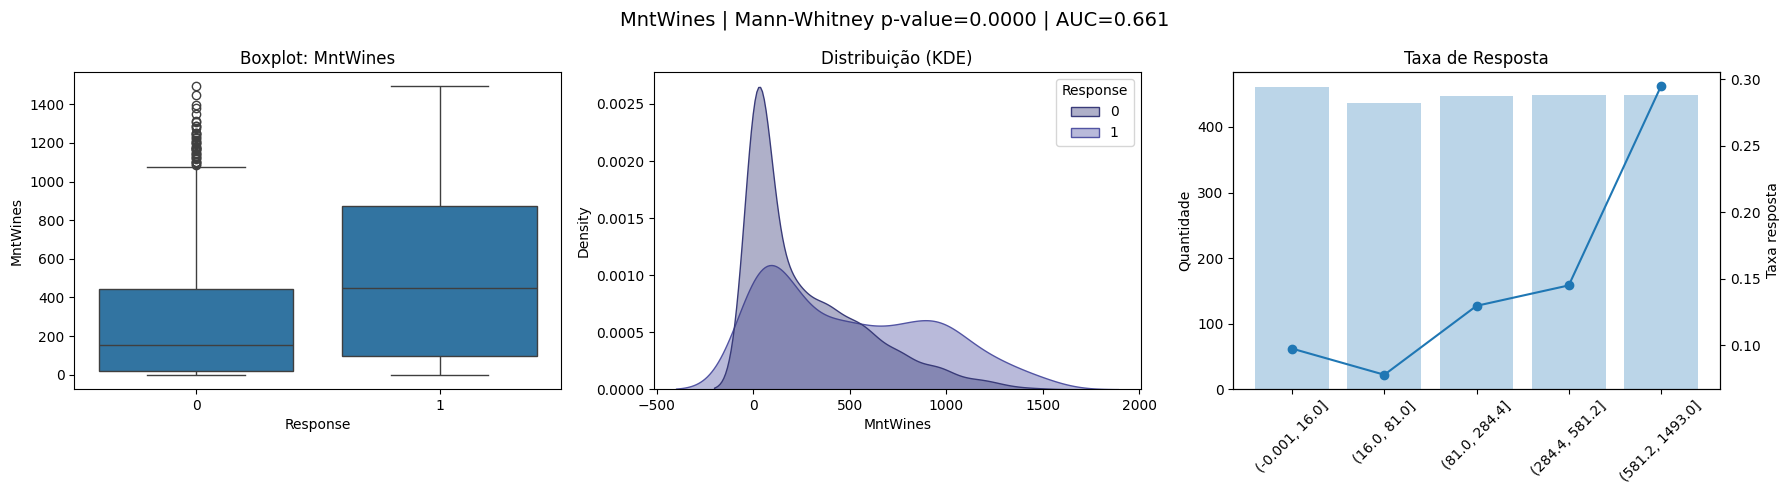

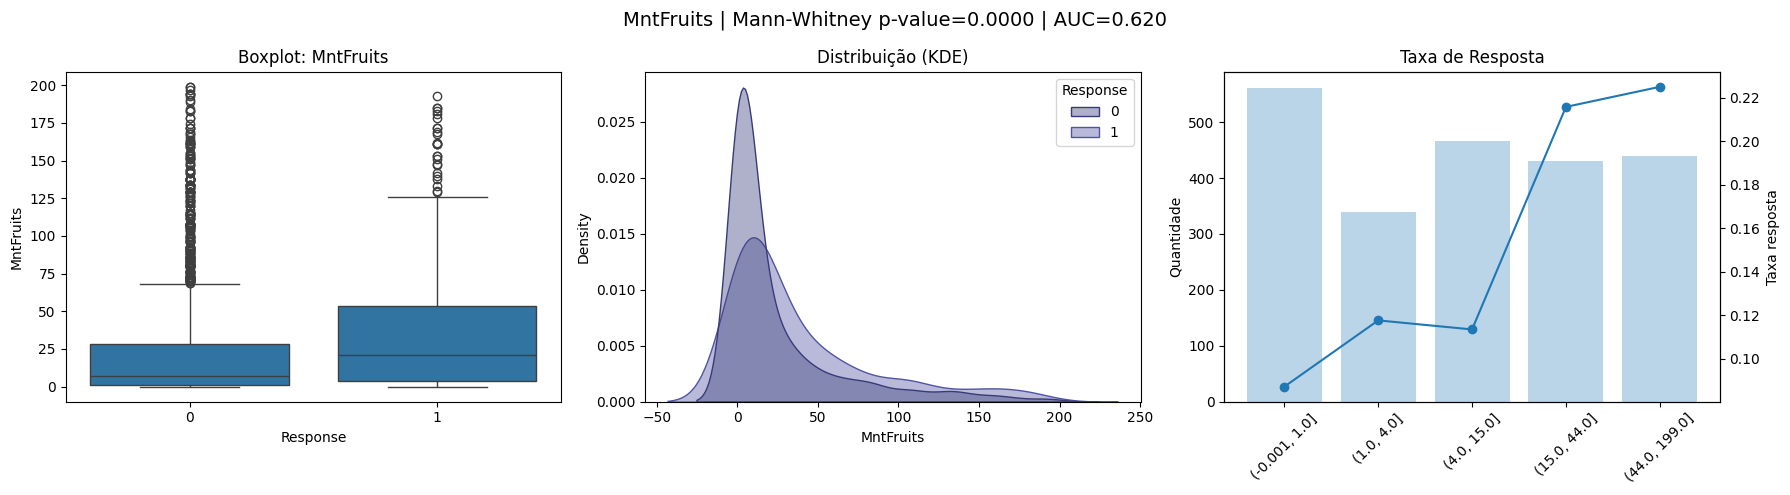

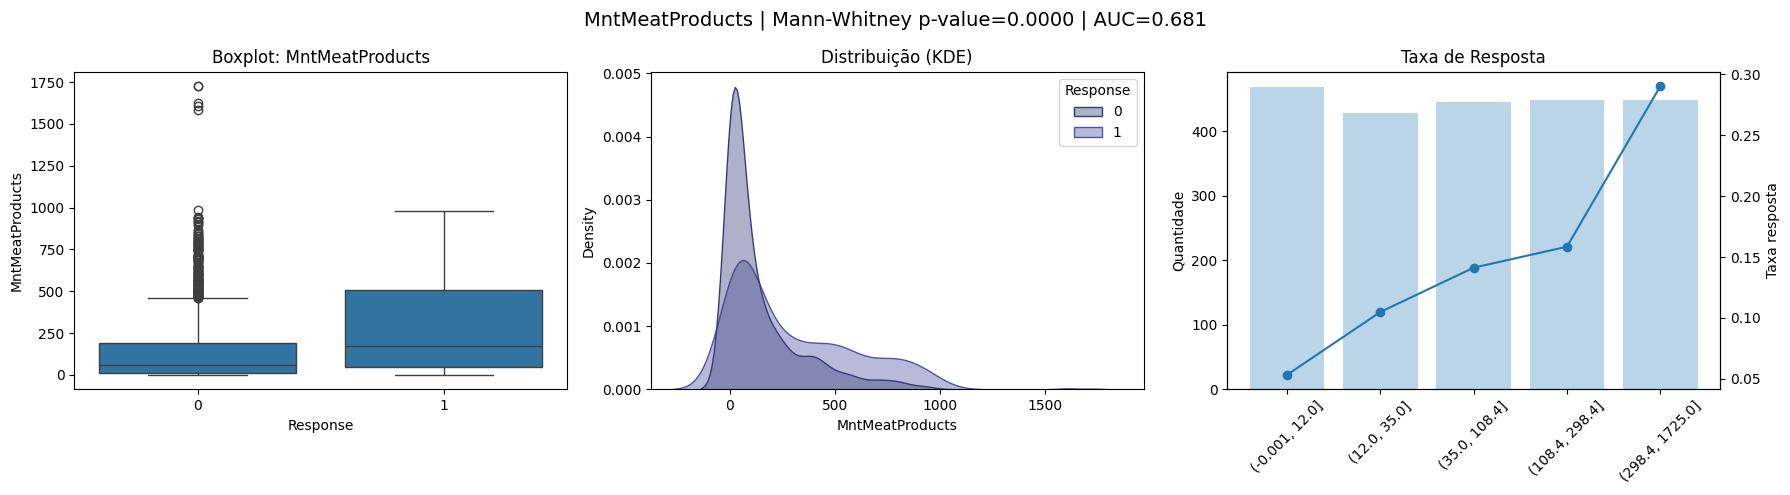

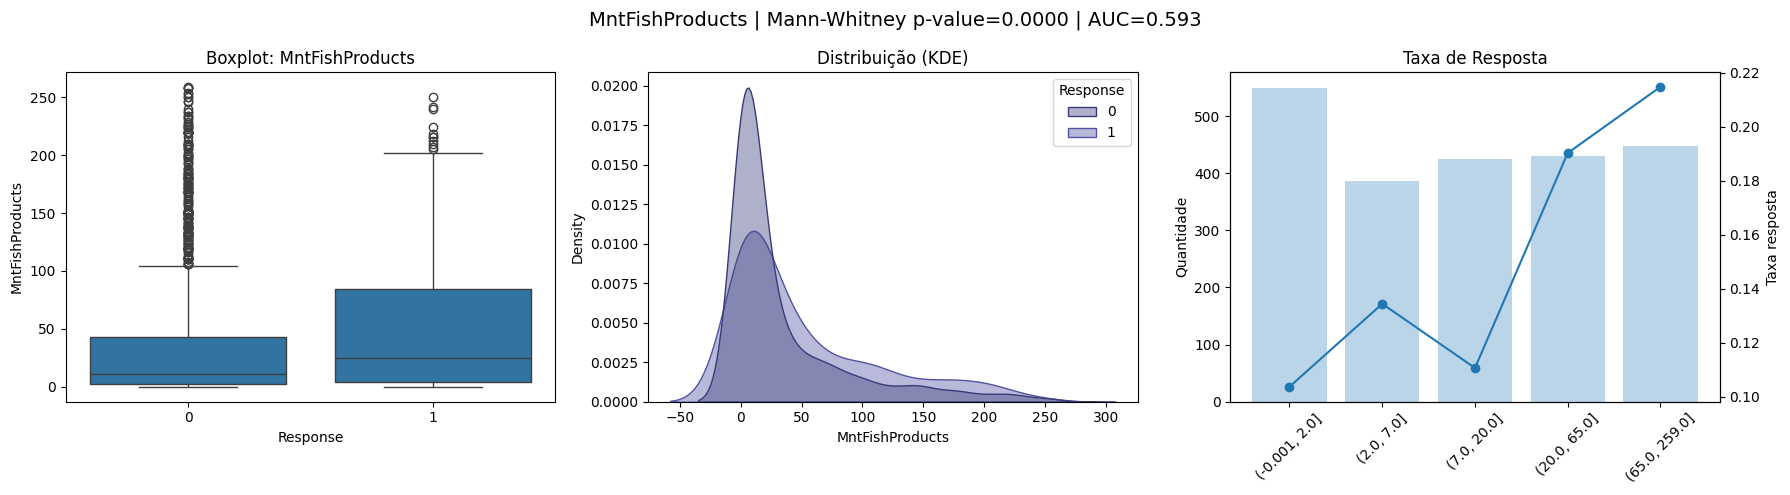

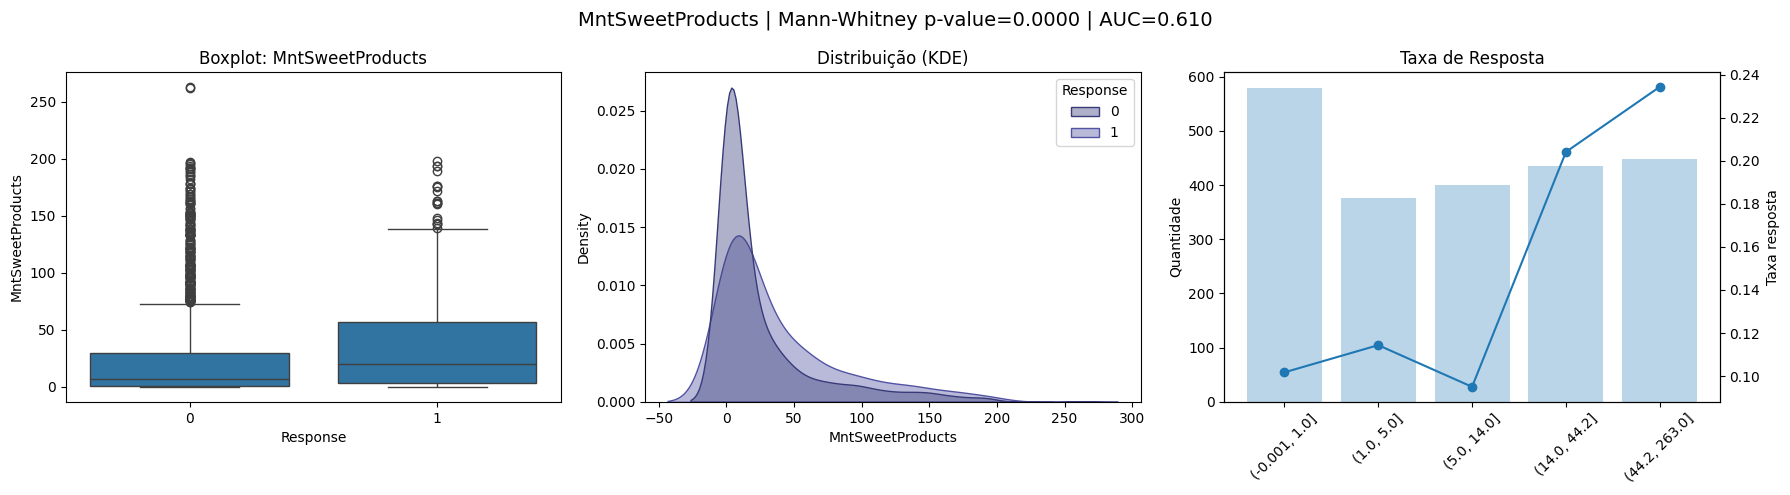

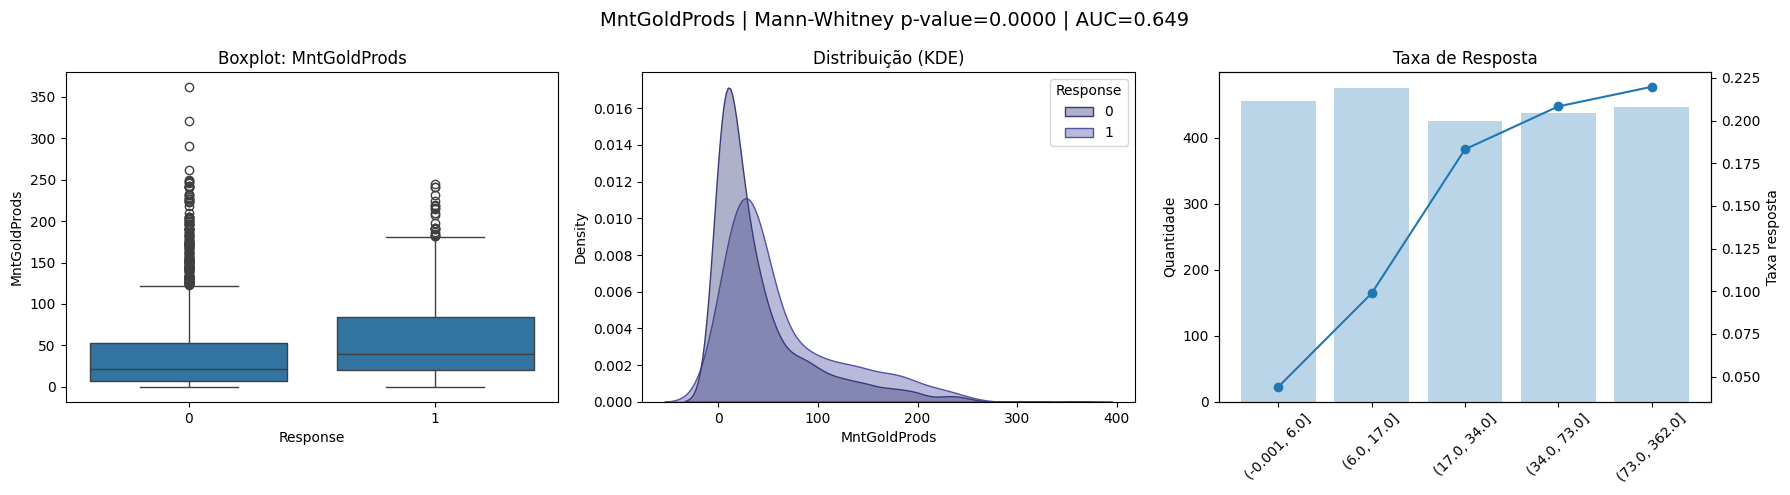

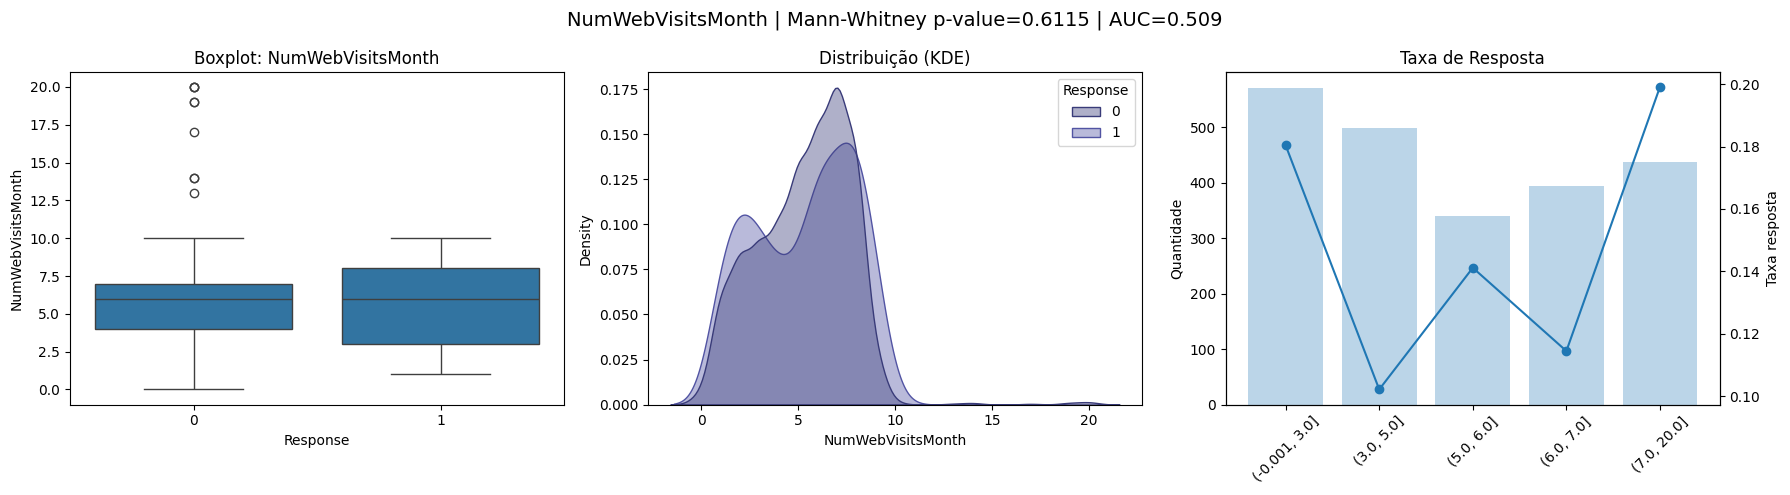

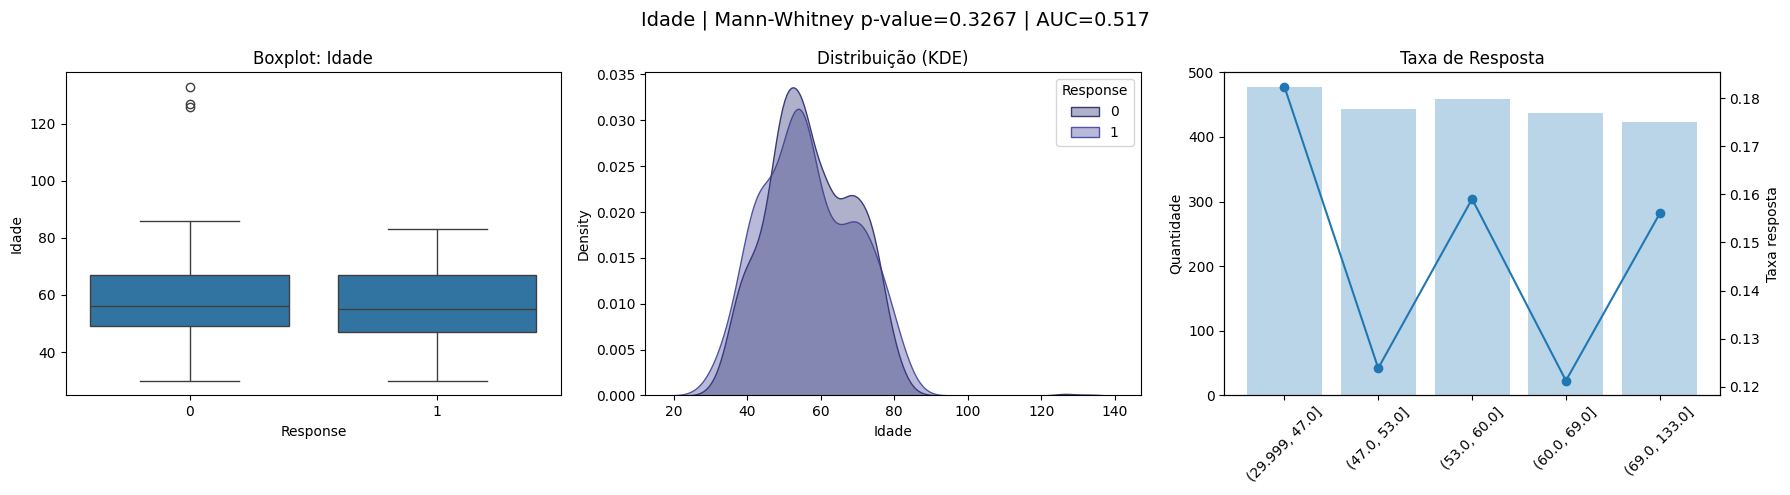

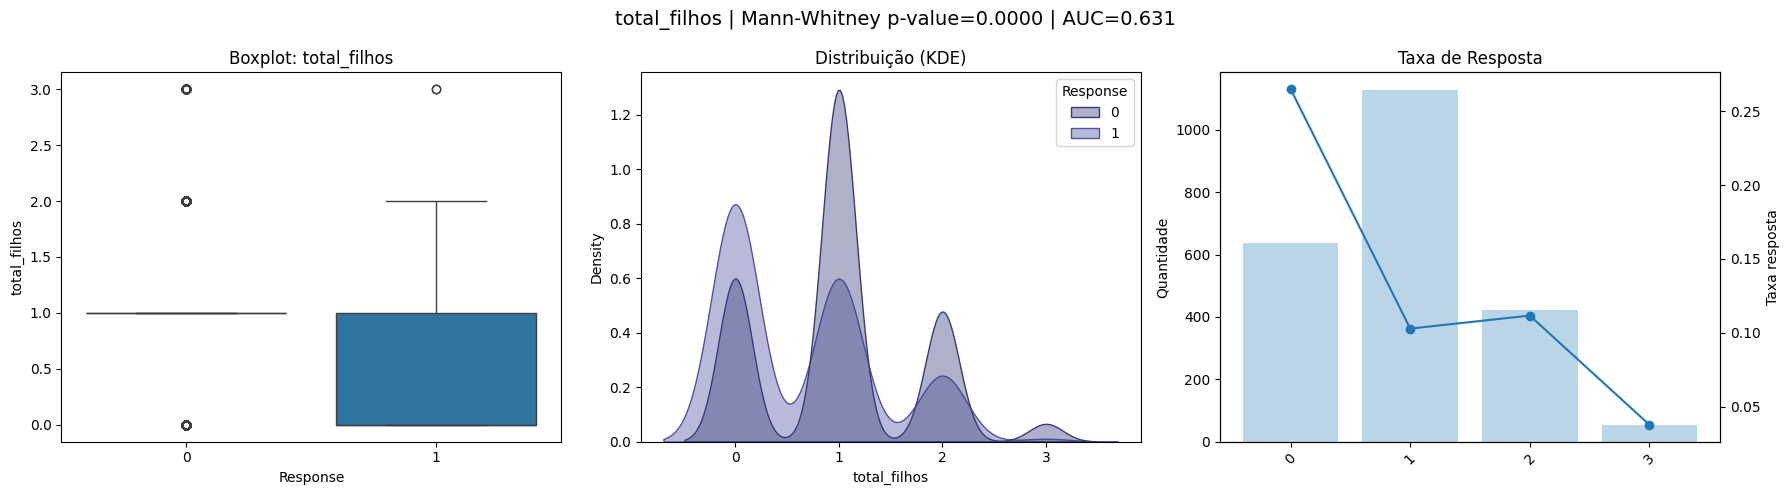

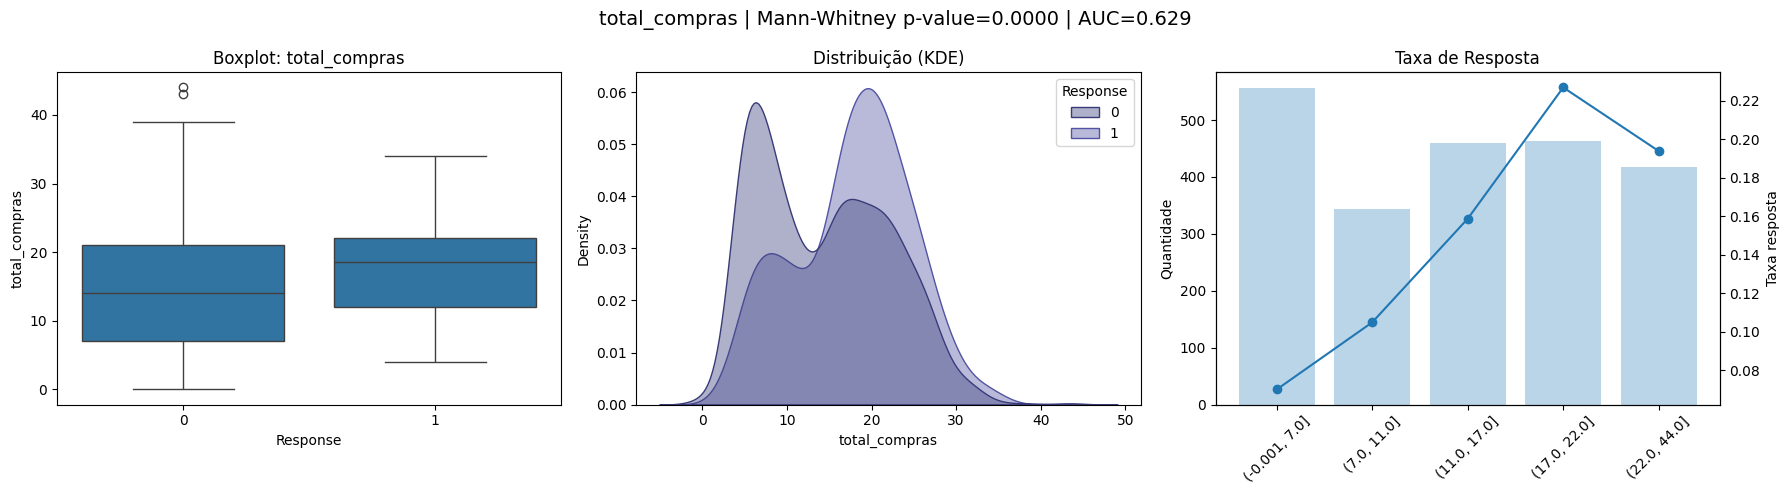

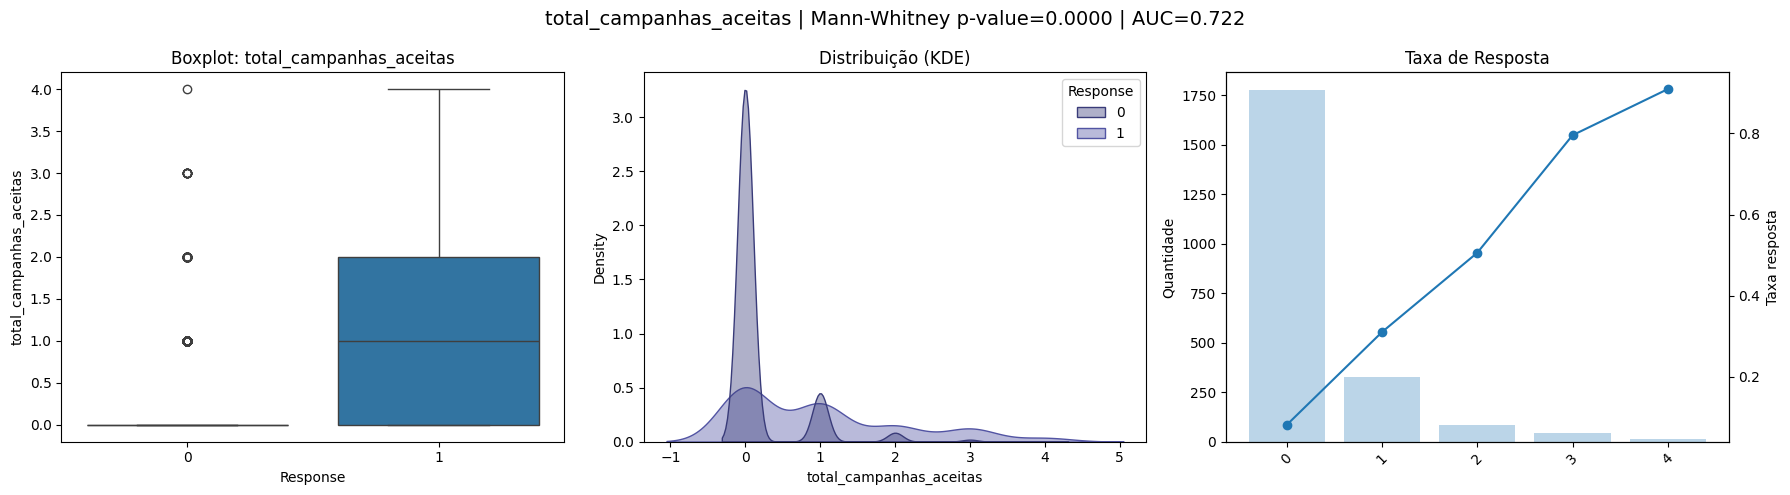

In [50]:
for var in var_numericas:
    eda_bivariada_numerica(df_crm, var, "Response")

#### Conclusões

Como interpretar as métricas

- Mann-Whitney p-value
    - p < 0.05 → distribuições entre Response=0 e Response=1 são diferentes
    - p > 0.05 → pouca evidência de separação

- AUC univariado

| AUC       | Interpretação |
| --------- | ------------- |
| 0.50–0.55 | Muito fraco   |
| 0.55–0.60 | Fraco         |
| 0.60–0.70 | Moderado      |
| 0.70–0.80 | Forte         |
| >0.80     | Muito forte   |


- Taxa de resposta por bins
    - subir continuamente → ótimo sinal
    - subir parcialmente → útil
    - comportamento aleatório → pouca informação

- Variáveis com maior destaque:
    - total_campanhas_aceitas
        - forte separação das classes
        - Clientes com maior participação em campanhas anteriores, apresentam uma tendência maior de responder.
    - MntMeatProducts
        - Separação entre as classes
        - Taxa de resposta crescente
        - Clientes que gastam mais com carnes, apresentam uma tendência maior a responder mais.
    - MntWines
        - Separação entre as classes
        - Taxa de resposta sobe muito forte na ultima faixa de gastos
        - Clientes que gastam mais com vinhos, apresentam uma tendência maior a responder mais.
    - MntGoldProducts
        - Separação entre as classes
        - Taxa de resposta crescente
        - Clientes que consomem produtos premium, apresentam uma tendência maior a responder mais.
- Variáveis moderadas:
    - total_filhos
        - Separação entre as classes
        - Taxa de resposta maior em 0 filhos, com uma estabilidade entre 1 e 2 filhos e queda no caso de 3 filhos.
        - Clientes que não possuem filhos, apresentam uma tendência maior a responder mais.
    - total_compras
        - Separação razoável entre as classes
        - Taxa de resposta crescente, havendo uma pequena queda na ultima faixa.
        - Clientes que compram mais, apresentam uma tendência maior a responder mais.
    - MntFruits
        -  Apresenta uma taxa de resposta com forte crescimento entre a terceira e quarta faixa de gastos
        - Clientes entre as duas ultimas faixas de gasto, apresentam uma tendência maior a responder mais.
    - MntSweetProducts
        - Comportamento semelhante a variável MntFruits
- Variáveis fracas:
    - MntFishProducts
        - Comportamento semelhante a variável MntFruits, porém com AUC = 0,59
- Variáveis a serem removidas:
    - Idade: 
        - Boxplots sobrepostos
        - p_valor = 0,32 
        - Transformar em faixas etárias pode ser uma alternativa
    - NumWebVisitsMonth: 
        - Boxplots sobrepostos
        - p_valor = 0,61

In [245]:
df_crm.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Idade,faixa_etaria,faixa_renda_anual,tem_filhos,total_filhos,total_gasto,total_compras,ticket_medio,total_campanhas_aceitas,faixa_recencia,pct_gasto_vinhos,pct_gasto_frutas,pct_gasto_carnes,pct_gasto_peixes,pct_gasto_doces,pct_gasto_premium,cliente_aceita_campanha,pct_compras_deals,pct_compras_web,pct_compras_catalog,pct_compras_store,canal_preferencial,nivel_educacional,estado_civil
0,1957,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,69,60_mais,Alta,0,0,1617,25,64.680000,0,Recente,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0,0.120000,0.320000,0.400000,0.160000,Catalogo,medio,Single
1,1954,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,72,60_mais,Media,1,2,27,6,4.500000,0,Recente,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0,0.333333,0.166667,0.166667,0.333333,Loja,medio,Single
2,1965,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,61,60_mais,Muito_Alta,0,0,776,21,36.952381,0,Muito_Recente,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0,0.047619,0.380952,0.095238,0.476190,Loja,medio,Together
3,1984,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,42,41_50,Baixa,1,1,53,8,6.625000,0,Muito_Recente,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0,0.250000,0.250000,0.000000,0.500000,Loja,medio,Together
4,1981,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,45,41_50,Alta,1,1,422,19,22.210526,0,Inativo,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0,0.263158,0.263158,0.157895,0.315789,Loja,alto,Married


In [242]:
def eda_bivariada_porcentagem_entre_grp_target(df, vars, target):

    n = len(vars)
    cols = 3
    rows = (n // cols) + (n % cols > 0)

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows*4))
    axes = axes.flatten()

    for i, var in enumerate(vars):

        # Executando o Teste qui-quadrado
        table = pd.crosstab(df[var], df[target])

        chi2, p_valor, _, _ = chi2_contingency(table)

        df_grouped = df.groupby(var)[target].value_counts(normalize=True)
        df_grouped = df_grouped.mul(100)
        df_grouped = df_grouped.rename('porcentagem').reset_index()
        df_grouped['frequencia'] = df.groupby(var)[target].value_counts().values 
        # df_grouped['var_freq'] = df_grouped[var].astype(str) + ' (n=' + df_grouped["frequencia"].astype(str) + ')'     
        df_grouped['var_freq'] = df_grouped[var].astype(str) + ' (n' + df_grouped['Response'].astype(str) + '=' + df_grouped["frequencia"].astype(str) + ')'
        ax1 = axes[i]

        sns.barplot(data=df_grouped, x='var_freq', y='porcentagem', hue=target, palette='tab20b', orient='v',  ax=ax1, legend='auto', )            

        legend = ax1.get_legend()
        legend.set_bbox_to_anchor((1, 1))

        ax1.set_title(f"{var} | Qui² p-value={p_valor:.5f} | Cramér´s V: {contingency.association(table,method='cramer'):.5f}", fontsize=10, loc='left', fontweight=600)
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=80, fontsize=8, ha='center')
        ax1.set_xlabel('')
        ax1.set_ylabel('')
        ax1.set_yticklabels(labels=[], visible=False)
        ax1.set_yticks([])

        for container in ax1.containers:
            ax1.bar_label(container, labels = [f' {v.get_height():.2f}%' if v.get_height() > 0 else '' for v in container], label_type='edge', fontsize=8)


    # remove eixos vazios
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    sns.despine()
    plt.tight_layout()
    plt.show()

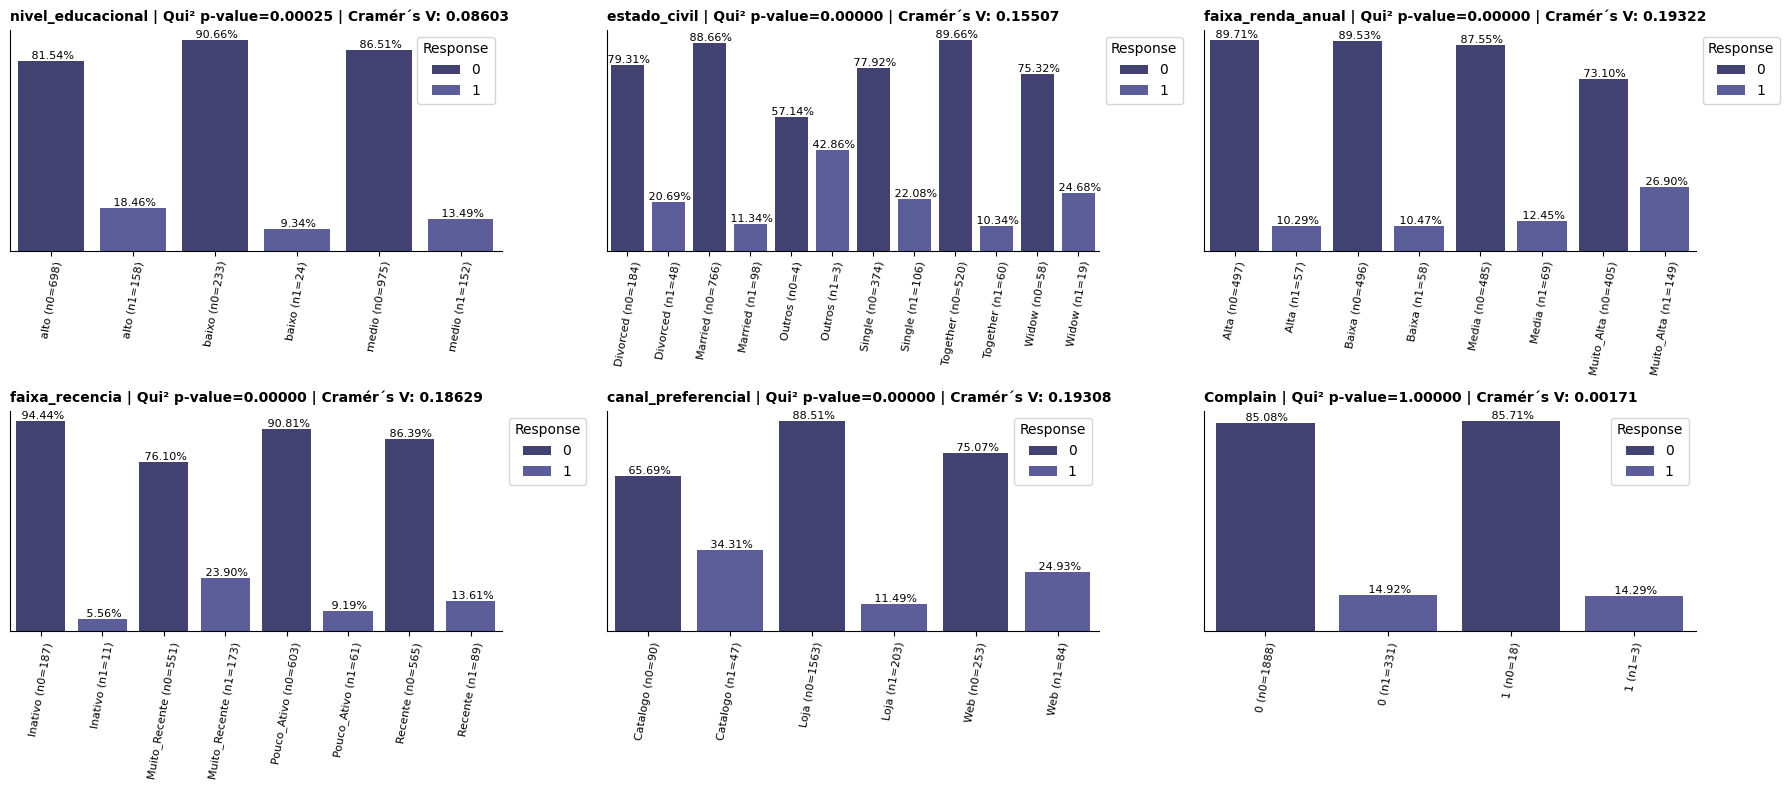

In [243]:
eda_bivariada_porcentagem_entre_grp_target(df=df_crm, vars=var_categoricas, target='Response')

#### Conclusões

Qui²  p-value
- p < 0.05 → Há uma associação estatisticamente significativa entre as variáveis categóricas testadas.
- p > 0.05 → Não se rejeita a hipótese nula. Não há evidências suficientes para afirmar que existe associação entre as variáveis.

Com os valores de Cramér's V, podemos responder, Existe associação, e ela é forte o suficiente para ter relevancia?
- Como interpretar o Cramér's V

| Cramér's V  |            Interpretação |
| ----------- | -----------------------: |
| < 0.05      | praticamente inexistente |
| 0.05 – 0.10 |              muito fraca |
| 0.10 – 0.20 |         fraca a moderada |
| 0.20 – 0.40 |                 moderada |
| > 0.40      |                    forte |

Com isso, iremos avaliar cada variável X e sua associação com target.
- Variáveis com maior destaque:
    - canal_preferencial: Clientes cujo canal preferencial é catálogo, apresentam uma tendência maior (26,90%) de responder as campanhas.
    - faixa_renda_anual : Clientes com faixa de renda muito alta, apresentam tendência maior (34,31%) de responder as campanhas.
    - faixa_recencia: Clientes mais recentes, apresentam tendência maior (37,51%) de responder as campanhas.
- Variáveis moderadas:
    - estado_civil: Podemos observar que a categoria Outros se destaca, porém apresenta um volume muito baixo, com apenas 7 registros no total. Vou reagrupar essa categoria e reavaliar.
- Variáveis fracas:
    - nivel_educacional: Clientes com nível educacional alto, apresentam tendência maior (18,46%) de responder as campanhas.
- Remover a variável Complain: p_valor = 1 (não existe associação) e Cramér's V = 0,001.

In [246]:
df_crm['estado_civil'].value_counts()

estado_civil
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Outros        7
Name: count, dtype: int64

In [247]:
# reagrupando as categorias de estado_civil
df_crm['estado_civil'] = df_crm['estado_civil'].replace({
    'Married': 'Casado',
    'Together': 'Casado',
    'Single': 'Solteiro',
    'Divorced': 'Outros',
    'Widow': 'Viúvo',
    'Outros': 'Outros'
})

In [248]:
df_crm['estado_civil'].value_counts()

estado_civil
Casado      1444
Solteiro     480
Outros       239
Viúvo         77
Name: count, dtype: int64

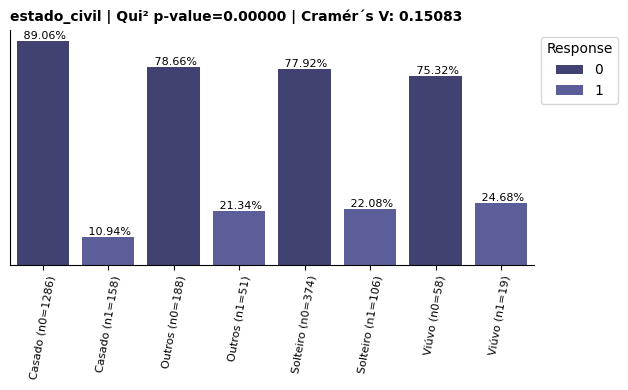

In [250]:
eda_bivariada_porcentagem_entre_grp_target(df=df_crm, vars=['estado_civil'], target='Response')

- Com o reagrupamento das categorias da variável estado_civil, temos agora a categoria Outros com um volume mais razoável n=239.
- Clientes sem parceiro (Solteiro, Viuvo e Outros), apresentam tendência maior de responder as campanhas.

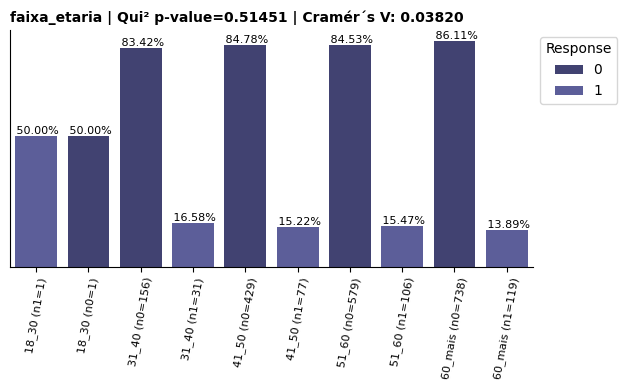

In [271]:
eda_bivariada_porcentagem_entre_grp_target(df=df_crm, vars=['faixa_etaria'], target='Response')

In [265]:
var_categoricas = ['nivel_educacional',
 'estado_civil',
 'faixa_renda_anual',
 'faixa_recencia',
 'canal_preferencial',
 'faixa_etaria']

In [266]:
var_numericas = ['MntWines', 'MntFruits', 'MntMeatProducts'
                 , 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
                 ,'total_filhos','total_compras','total_campanhas_aceitas']

In [267]:
dummies_vif = pd.get_dummies(
    df_crm[var_categoricas + var_numericas],
    columns=['nivel_educacional','estado_civil','faixa_etaria',  'faixa_renda_anual', 'faixa_recencia', 'canal_preferencial'], 
    drop_first=True, dtype=int
)

In [268]:
dummies_vif.head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_filhos,total_compras,total_campanhas_aceitas,nivel_educacional_baixo,nivel_educacional_medio,estado_civil_Outros,estado_civil_Solteiro,estado_civil_Viúvo,faixa_etaria_31_40,faixa_etaria_41_50,faixa_etaria_51_60,faixa_etaria_60_mais,faixa_renda_anual_Baixa,faixa_renda_anual_Media,faixa_renda_anual_Muito_Alta,faixa_recencia_Muito_Recente,faixa_recencia_Pouco_Ativo,faixa_recencia_Recente,canal_preferencial_Loja,canal_preferencial_Web
0,635,88,546,172,88,88,0,25,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
1,11,1,6,2,1,6,2,6,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,1,1,0
2,426,49,127,111,21,42,0,21,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0
3,11,4,20,10,3,5,1,8,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0
4,173,43,118,46,27,15,1,19,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [269]:
calcular_vif(dummies_vif, dummies_vif.columns.tolist())

,variavel,VIF
0,const,494.579997
18,faixa_etaria_60_mais,108.580564
17,faixa_etaria_51_60,97.743693
16,faixa_etaria_41_50,80.417191
15,faixa_etaria_31_40,35.718706
1,MntWines,3.411926
25,canal_preferencial_Loja,3.411732
26,canal_preferencial_Web,3.359447
8,total_compras,3.208068
22,faixa_recencia_Muito_Recente,3.181788


#### Observações
- A variável Idade foi retirada por apresentar resultados ruins na avaliação de associação com a variável Response: - AUC = 0.517 - Muito fraca. - p-value alto = 0.32 - Distribuições quase iguais.
- Foi utilizada em seu lugar a variável faixa_etaria, porém também apresentou Qui² = não significativo e Cramér's V = praticamente zero.
- Minha decisão final é remover ambas as variáveis.

### Análise da relação linear entre as variáveis independentes numéricas e a variável y (logito p)

In [273]:
var_numericas

['MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'total_filhos',
 'total_compras',
 'total_campanhas_aceitas']

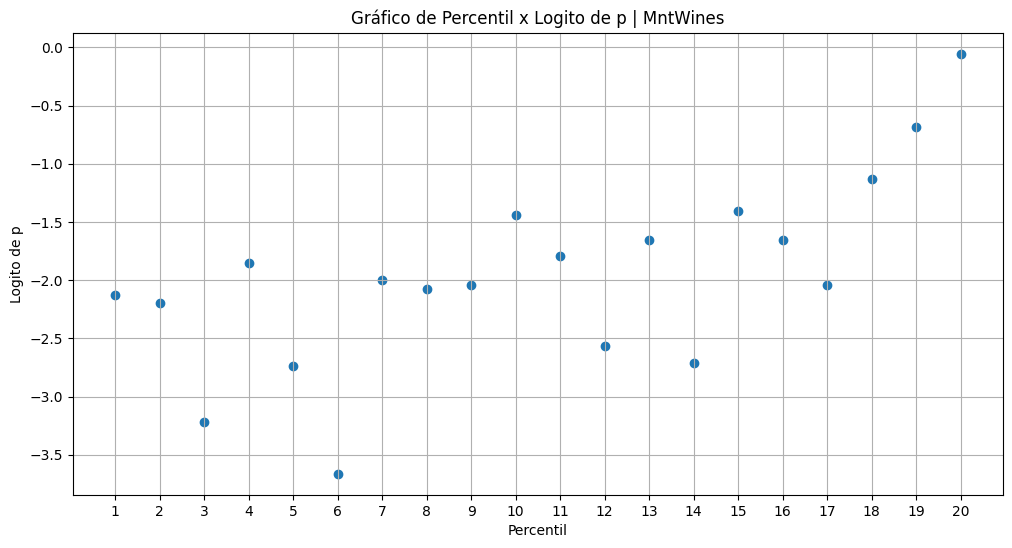

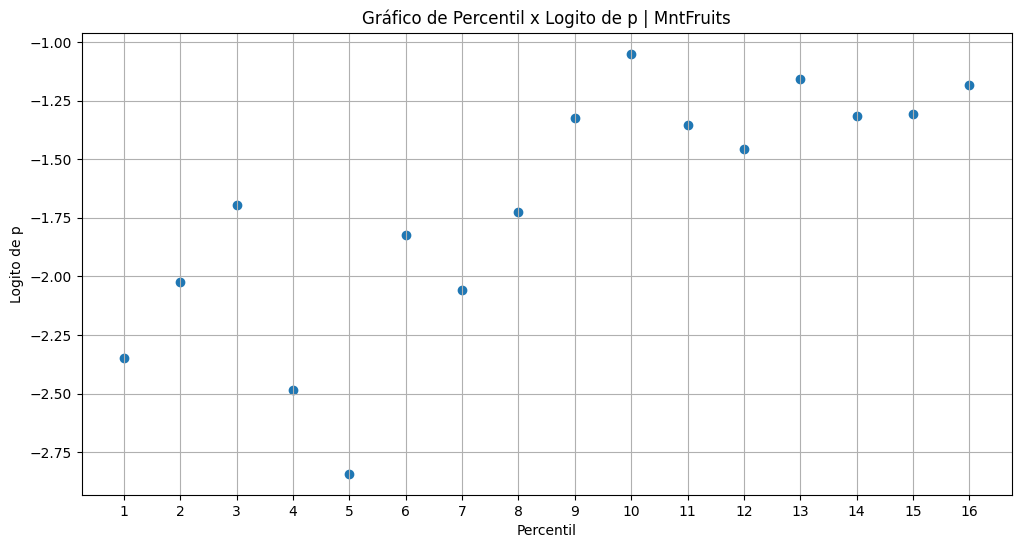

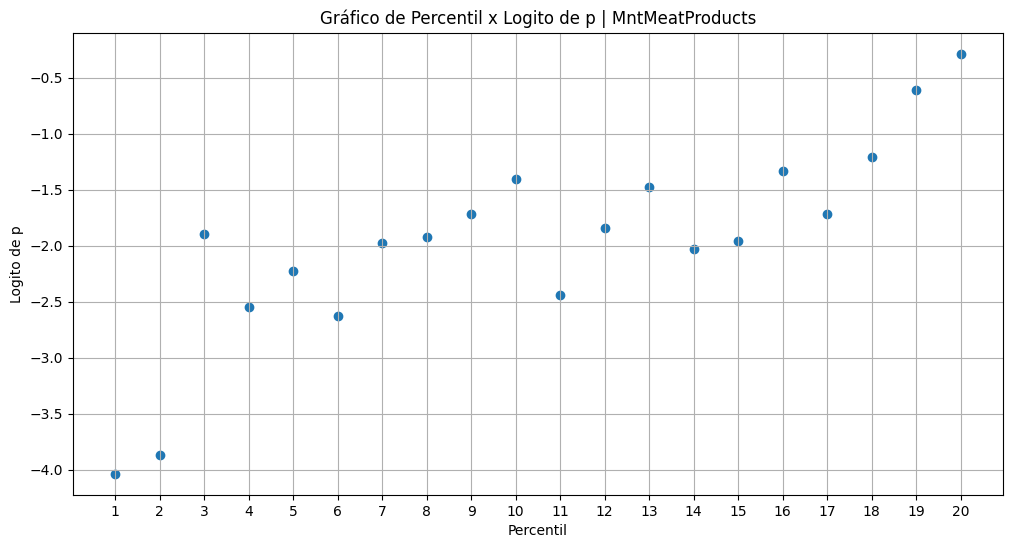

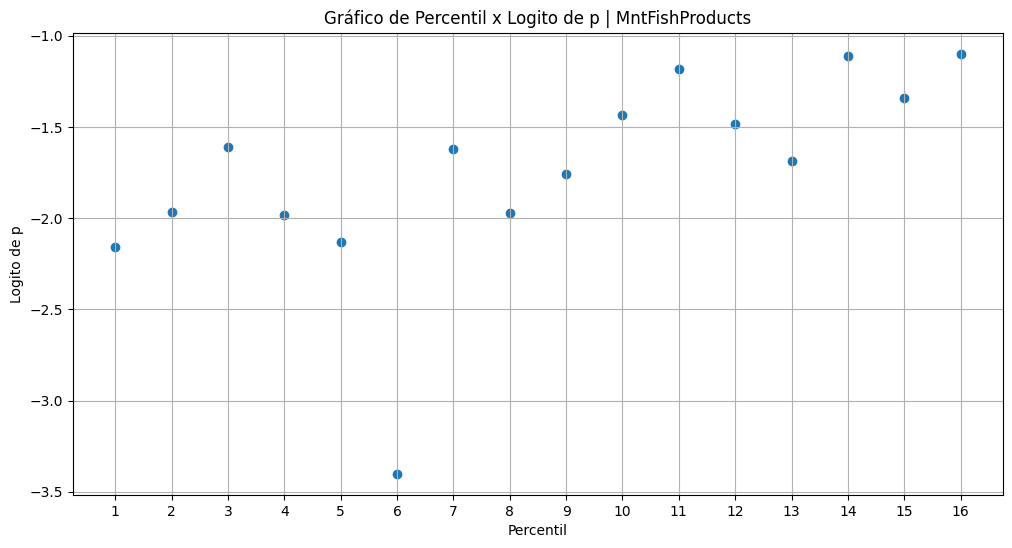

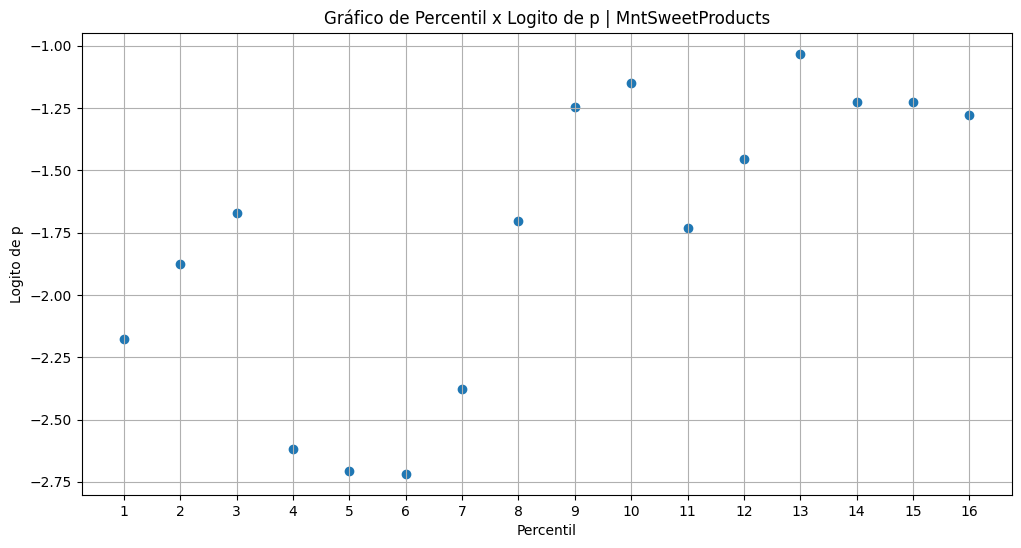

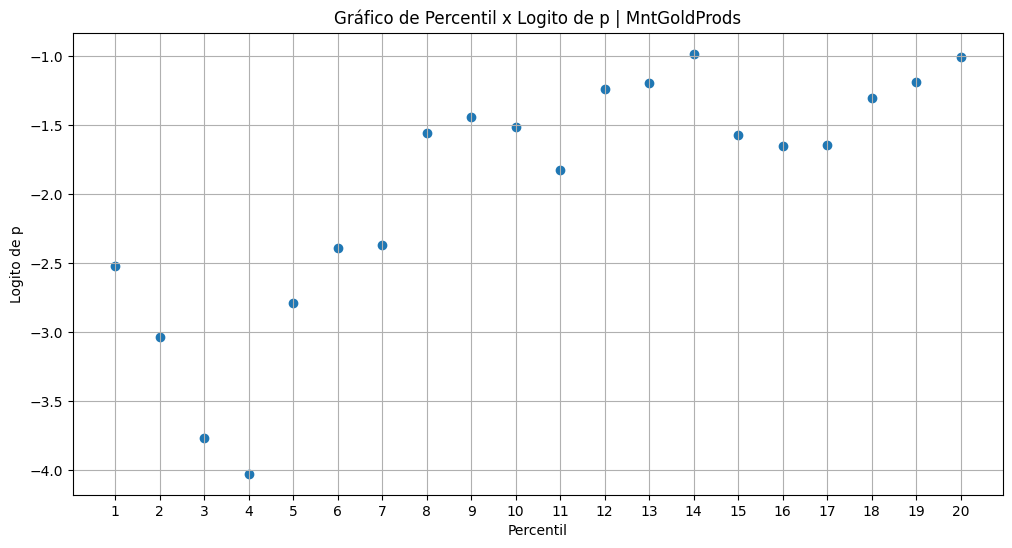

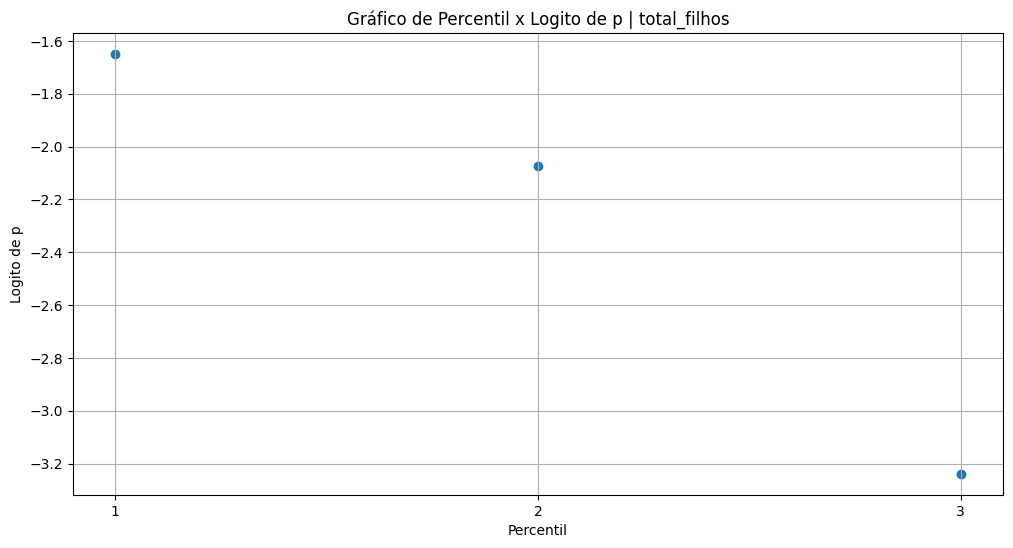

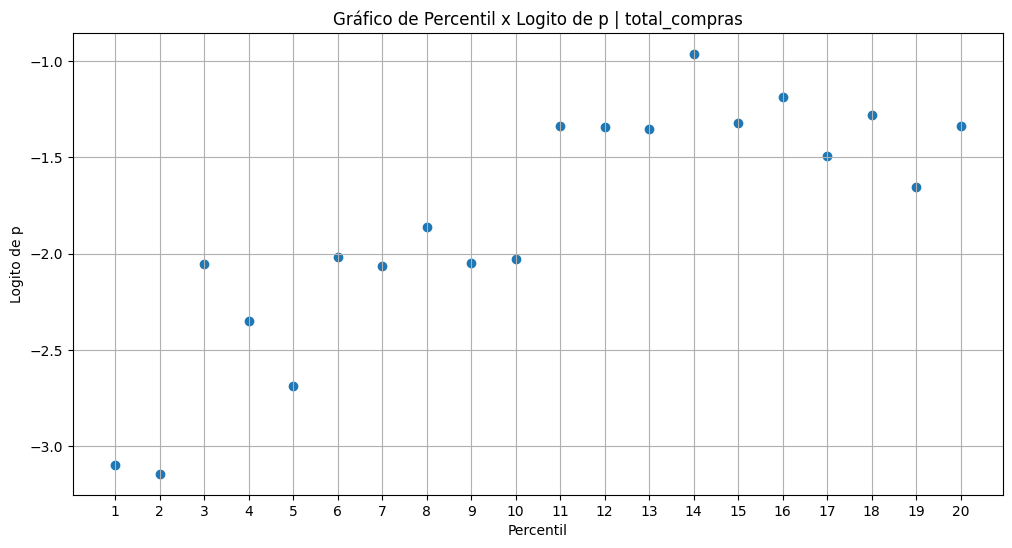

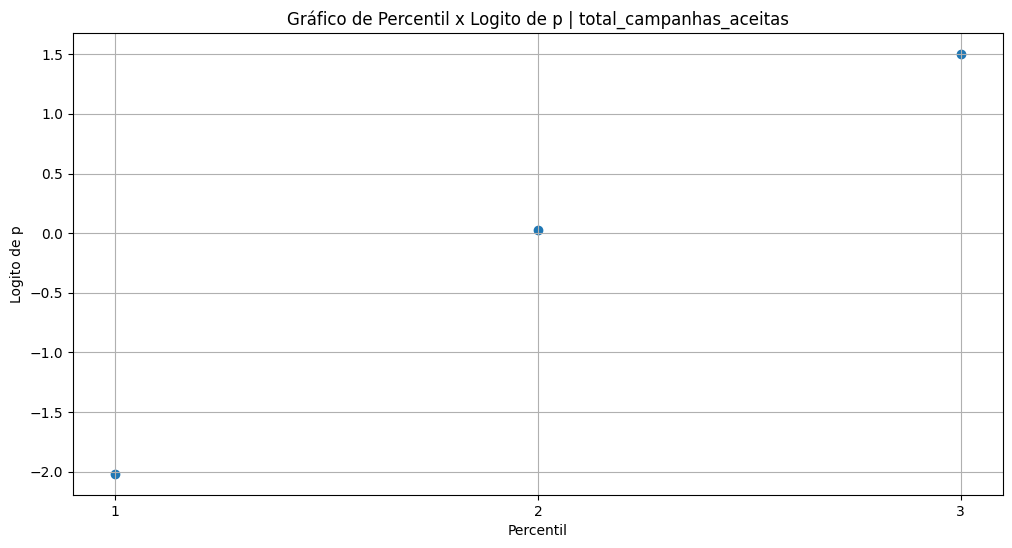

In [274]:
for var in var_numericas:
    rl.analise_var_numerica_por_percentil(data=df_crm, x=var, y='Response',q=20,grafico='logito')

#### Conclusões
- Nenhuma dessas variáveis apresenta uma não-linearidade forte o suficiente para justificar a categorização em faixas (bins).

In [276]:
var_numericas

['MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'total_filhos',
 'total_compras',
 'total_campanhas_aceitas']

In [278]:
var_categoricas = ['nivel_educacional',
 'estado_civil',
 'faixa_renda_anual',
 'faixa_recencia',
 'canal_preferencial']

In [279]:
df_crm.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Idade,faixa_etaria,faixa_renda_anual,tem_filhos,total_filhos,total_gasto,total_compras,ticket_medio,total_campanhas_aceitas,faixa_recencia,pct_gasto_vinhos,pct_gasto_frutas,pct_gasto_carnes,pct_gasto_peixes,pct_gasto_doces,pct_gasto_premium,cliente_aceita_campanha,pct_compras_deals,pct_compras_web,pct_compras_catalog,pct_compras_store,canal_preferencial,nivel_educacional,estado_civil
0,1957,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,69,60_mais,Alta,0,0,1617,25,64.680000,0,Recente,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0,0.120000,0.320000,0.400000,0.160000,Catalogo,medio,Solteiro
1,1954,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,72,60_mais,Media,1,2,27,6,4.500000,0,Recente,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0,0.333333,0.166667,0.166667,0.333333,Loja,medio,Solteiro
2,1965,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,61,60_mais,Muito_Alta,0,0,776,21,36.952381,0,Muito_Recente,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0,0.047619,0.380952,0.095238,0.476190,Loja,medio,Casado
3,1984,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,42,41_50,Baixa,1,1,53,8,6.625000,0,Muito_Recente,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0,0.250000,0.250000,0.000000,0.500000,Loja,medio,Casado
4,1981,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,45,41_50,Alta,1,1,422,19,22.210526,0,Inativo,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0,0.263158,0.263158,0.157895,0.315789,Loja,alto,Casado


In [280]:
df_crm = df_crm[var_categoricas + var_numericas + ['Response']]
df_crm.head()

,nivel_educacional,estado_civil,faixa_renda_anual,faixa_recencia,canal_preferencial,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_filhos,total_compras,total_campanhas_aceitas,Response
0,medio,Solteiro,Alta,Recente,Catalogo,635,88,546,172,88,88,0,25,0,1
1,medio,Solteiro,Media,Recente,Loja,11,1,6,2,1,6,2,6,0,0
2,medio,Casado,Muito_Alta,Muito_Recente,Loja,426,49,127,111,21,42,0,21,0,0
3,medio,Casado,Baixa,Muito_Recente,Loja,11,4,20,10,3,5,1,8,0,0
4,alto,Casado,Alta,Inativo,Loja,173,43,118,46,27,15,1,19,0,0


In [281]:
# salvar base de dados analise bivariada
df_crm.to_csv('../data/crm_eda_bivariada.csv', index=False)